In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml import PipelineModel
import os

# 1. Start Spark
spark = SparkSession.builder.appName("Phase3_Evaluation").getOrCreate()

# 2. Load the Data 
targetStation = "STN_0001"
gold_path = "data/gold/station_flow"
gold_df_path = "data/gold/bixi_gold.parquet" 
gold_df = spark.read.parquet(gold_path).filter(F.col("station_id") == targetStation)

# 3. Define the constants needed for the script
targetStation = "STN_0001"
test_date = "2025-08-01 00:00:00"

print(f"✅ Spark active and gold_df loaded with {gold_df.count():,} rows.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/18 01:25:02 WARN Utils: Your hostname, Comanes-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.11 instead (on interface en0)
26/04/18 01:25:02 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/18 01:25:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/18 01:25:03 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/18 01:25:03 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


✅ Spark active and gold_df loaded with 24,614 rows.


In [2]:
from pyspark.ml import PipelineModel
from lossfunction import asymmetric_loss_mean

# 1. SETUP
targetStation = "STN_0001"
test_date = "2025-08-01 00:00:00"

# 2. LOAD YOUR CHOSEN CHAMPIONS
print("Loading the Winning Models...")
# Outflow was RF
outflow_model = PipelineModel.load(f"models/{targetStation}/outflow_RF_optimized")
# Inflow was RF
inflow_model = PipelineModel.load(f"models/{targetStation}/inflow_RF_optimized")

# 3. GENERATE JOINT PREDICTIONS ON TEST DATA
test_df = gold_df.filter((F.col("station_id") == targetStation) & (F.col("ts_hour") >= test_date))

preds_out = outflow_model.transform(test_df).withColumnRenamed("prediction", "pred_out")
preds_in = inflow_model.transform(test_df).withColumnRenamed("prediction", "pred_in")

# Join them together
df_results = preds_out.select("ts_hour", "station_outflow", "station_inflow", "pred_out") \
    .join(preds_in.select("ts_hour", "pred_in"), on="ts_hour")

# 4. CALCULATE NETFLOW
# Actual: What really happened
# Predicted: What your RF/GBT combo thinks will happen
df_results = df_results.withColumn("actual_netflow", F.col("station_inflow") - F.col("station_outflow")) \
                       .withColumn("pred_netflow", F.col("pred_in") - F.col("pred_out")) \
                       .withColumn("error", F.col("actual_netflow") - F.col("pred_netflow"))

# 5. THE BUSINESS LITMUS TEST (Asymmetric Loss)
# Alpha=1.5 (Penalize underestimating netflow/empty stations)
# Beta=1.0 (Standard penalty for overestimating)
total_business_loss = asymmetric_loss_mean(df_results, "actual_netflow", "pred_netflow", alpha=1.5, beta=1.0)

print("\n" + "="*35)
print(f"🏆 PHASE 3 EVALUATION: {targetStation}")
print("="*35)
print(f"Final Business Loss Score: {total_business_loss:.4f}")
print("="*35)

Loading the Winning Models...


26/04/18 01:25:10 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.



🏆 PHASE 3 EVALUATION: STN_0001
Final Business Loss Score: 31.7730


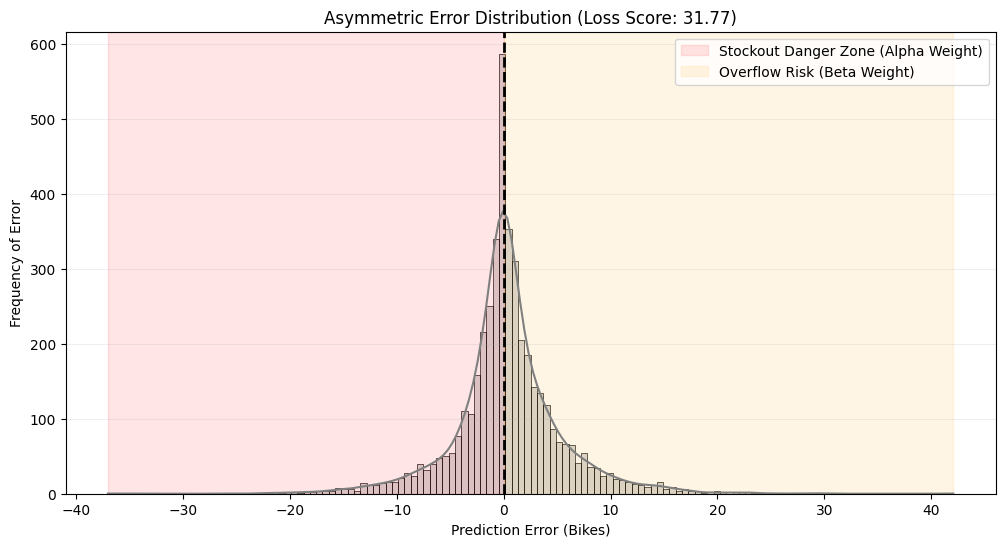

In [3]:
## model assymmetric loss graph

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the Residuals
# Residual = Actual Netflow - Predicted Netflow
pdf = df_results.select("actual_netflow", "pred_netflow").toPandas()
pdf['residual'] = pdf['actual_netflow'] - pdf['pred_netflow']

# 2. Create the Graph
plt.figure(figsize=(12, 6))

# Plot the distribution of errors
sns.histplot(pdf['residual'], kde=True, color='gray', alpha=0.3)

# 3. Add the Asymmetric Shading
# Negative Residuals = Predicted more bikes leaving than arrived (Stockout Risk)
plt.axvspan(pdf['residual'].min(), 0, color='red', alpha=0.1, label='Stockout Danger Zone (Alpha Weight)')
# Positive Residuals = Predicted more bikes arriving than leaving (Overflow Risk)
plt.axvspan(0, pdf['residual'].max(), color='orange', alpha=0.1, label='Overflow Risk (Beta Weight)')

# Add the "Zero" line (Perfect Prediction)
plt.axvline(0, color='black', linestyle='--', linewidth=2)

# 4. Labeling for Business Context
plt.title(f"Asymmetric Error Distribution (Loss Score: {total_business_loss:.2f})")
plt.xlabel("Prediction Error (Bikes)")
plt.ylabel("Frequency of Error")
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

Left-Leaning (Red Zone): If the bulk of your graph is in the red zone, your combination is under-predicting arrivals. This is why your loss score is 32.5—the model is frequently putting the station at risk of being empty.

Right-Leaning (Orange Zone): If the hump is in the orange zone, you are over-predicting arrivals. This is a "cautious" model. It’s better for the business because the penalty (β) is lower.

Tall and Skinny: This means your MAE is great.